# Projet de Statistique Appliquée

## Étude comparative de l'efficacité des hôpitaux selon leur statut

Projet d'économétrie appliqué s'appuyant sur les données publiques de la Statistique Annuelle des Établissements (SAE) et d'Hospidiag.

### 1 - Importation des bibliothèques

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.iv import IV2SLS

### 2 - Importations des données

Extraction des Outputs et Inputs de 2022, dans un premiers temps on s'intéresse aux services d'Urgence, de Médecine, Chirurgie et obstétrique (MCO), Soins de suite et rééducation (SSR), Psychiatrie, Unité de soins de longue durée (USLD), et séances (séances de dyalise, de chimiothérapie, etc).

In [3]:
SYGEN2022 = pd.read_csv("SAE/2022/SYGEN_2022r.csv", sep=";", encoding="latin-1")
Data = SYGEN2022[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_INFSANSSPE','EFF_INFAVECSPE','EFF_AID','EFF_DIR','EFF_DIRSOI','EFF_AUTADM','SEJHC_SSR','SEJHC_MCO','SEJHP_MCO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEAN_HEMO_CENTRE','SEAN_CHIMIO','SEAN_RADIO']]

On extrait le statut des différents établissement depuis le fichier FINESS.xlsx obtenu sur le site SAE diffusion.
On crée une distinction entre les hôpitaux publics classiques qui serviront par la suite de référence et les grands hôpitaux publics, les CHU, en ajoutant une catégorie 'CHU' dans la colonne 'Statut'

In [4]:
FINESS = pd.read_excel("finess.xlsx")
FINESS = FINESS.rename(columns={"FINESS":"FI","Statut Juridique":"Statut"})

CHU = pd.read_excel("CHRU.xlsx")
CHU["FINESS"] = CHU["FINESS"].astype(object)

FINESS.loc[FINESS['Raison sociale'].isin(CHU['Raison sociale']), "Statut"] = "CHU"  #Ajout du statut CHU dans la colonne Statut de FINESS
FINESS = FINESS.drop(FINESS.columns[[1,2,4]],axis=1)  #supression des colonnes inutiles

Data = Data.merge(FINESS, on="FI", how="left")

In [5]:
print(Data.shape)
print(SYGEN2022.shape)

(3988, 20)
(3988, 208)


Extraction des données Hospidiag 2022 :

In [6]:
hd2022 = pd.read_csv("Hospidiag/hd2022.csv", sep=";", decimal = ",", encoding="utf-8")

Ajout des output des services d'urgences (nombre de passages) :

In [7]:
Urg2022 = pd.read_csv("SAE/2022/URGENCES2_2022r.csv", sep=";", encoding="latin-1")
Urg2022 = Urg2022[['FI','PASSU']]
Urg2022 = Urg2022.groupby("FI").sum().reset_index()  # Agrégation des données d'urgences par établissement
Data = Data.merge(Urg2022, on="FI", how="left")

Ajout des entrées au unités de soins longue durée (USLD) :

In [8]:
USLD2022 = pd.read_csv("SAE/2022/USLD_2022r.csv", sep=";", encoding="latin-1")
USLD2022 = USLD2022[['FI','ENT']]
Data = Data.merge(USLD2022, on="FI", how="left")

### 3 - Constructions des variables de la régression

#### 3.1 - Intputs

Total médecins (libéraux et saliariés confondus) : 

In [9]:
Data['EFF_MED'] = Data['EFFSAL_TOT'] + Data['EFFLIB_TOT'].fillna(0)
Data['EFF_MED'].describe()

count    3332.000000
mean       48.876351
std       102.023147
min         0.000000
25%         4.000000
50%        10.000000
75%        48.000000
max      1515.000000
Name: EFF_MED, dtype: float64

Total infirmiers (spécialisés et non-spécialisés) : 

In [10]:
Data['EFF_IDE'] = Data['EFF_INFSANSSPE'] + Data['EFF_INFAVECSPE'].fillna(0)
Data['EFF_IDE'].describe()

count    3530.000000
mean       97.522946
std       204.341642
min         0.000000
25%        11.000000
50%        24.000000
75%        75.000000
max      2090.000000
Name: EFF_IDE, dtype: float64

Total personnel administratif :

In [11]:
Data['EFF_ADMIN'] = Data['EFF_AUTADM'] + Data['EFF_DIRSOI'].fillna(0) + Data['EFF_DIR'].fillna(0)
Data["EFF_ADMIN"].describe()

count    3389.000000
mean       46.102980
std        88.991979
min         0.000000
25%         7.000000
50%        14.000000
75%        40.000000
max       952.000000
Name: EFF_ADMIN, dtype: float64

In [12]:
Data['EFF_DIR'].describe()

count    2616.000000
mean        3.435015
std         3.889435
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        64.000000
Name: EFF_DIR, dtype: float64

NB : la colonne 'EFF_DIRSOI' comptabilisant les effectifs de directeurs de soins par établissements n'a que 1050 lignes renseignées, sa prise en compte fait passer l'effectif moyen en personnel administratif de 62 à 63, l'influence de cette catégorie de personnel peut donc sans doute être considéré comme mineur.

#### 3.2 - Outputs

Total séjours MCO (hospitalisation partielle et complète confondu) :

In [13]:
Data['MCO'] = Data['SEJHP_MCO'] + Data['SEJHC_MCO']
Data['MCO'] = Data['MCO'].fillna(0)
Data['I_MCO'] = (Data['MCO'] > 0).astype(int)

Total séjours en psychiatrie (hospitalisations complètes, venues de jour et venues de nuit) :

In [14]:
Data['PSY'] = Data['SEJ_HTP_TOT'] + Data['VEN_HDJ_TOT'].fillna(0) + Data['VEN_HDN_TOT'].fillna(0)
Data['PSY'].describe()

count      512.000000
mean      7518.765625
std       7778.889299
min          0.000000
25%       1740.250000
50%       5311.000000
75%      10591.750000
max      47168.000000
Name: PSY, dtype: float64

In [15]:
Data['PSY'] = Data['PSY'].fillna(0)
Data['I_PSY'] = (Data['PSY'] > 0).astype(int)

In [16]:
Data["SEANCES"] = Data['SEAN_HEMO_CENTRE'].fillna(0) + Data['SEAN_CHIMIO'] + Data['SEAN_RADIO'].fillna(0)
Data["SEANCES"].describe()

count      728.000000
mean     10178.453297
std      15332.803292
min          0.000000
25%        573.000000
50%       3123.500000
75%      13299.250000
max      81352.000000
Name: SEANCES, dtype: float64

In [17]:
Data['SEANCES'] = Data['SEANCES'].fillna(0)
Data['I_SEANCES'] = (Data['SEANCES'] > 0).astype(int)

In [18]:
Data['PASSU'].describe()

count       623.000000
mean      34725.581059
std       24722.086305
min         314.000000
25%       16610.000000
50%       26651.000000
75%       46619.000000
max      132443.000000
Name: PASSU, dtype: float64

In [19]:
Data['PASSU'] = Data['PASSU'].fillna(0)
Data['I_URG'] = (Data['PASSU'] > 0).astype(int)

In [20]:
Data['PASSU'][Data['PASSU'] > 0]

0       42384.0
1       16727.0
13      22583.0
23      23369.0
24      38727.0
         ...   
3922    49067.0
3923    66717.0
3924    50064.0
3925    31213.0
3982    49595.0
Name: PASSU, Length: 623, dtype: float64

In [21]:
Data['ENT'].describe()

count    577.000000
mean      29.668977
std       21.068744
min        0.000000
25%       17.000000
50%       24.000000
75%       37.000000
max      167.000000
Name: ENT, dtype: float64

In [22]:
Data['ENT'] = Data['ENT'].fillna(0)
Data['I_USLD'] = (Data['ENT'] > 0).astype(int)

In [23]:
Data["SEJHC_SSR"].describe()

count    1802.000000
mean      474.011654
std       379.674641
min         0.000000
25%       220.000000
50%       377.000000
75%       633.750000
max      2755.000000
Name: SEJHC_SSR, dtype: float64

In [24]:
Data['SEJHC_SSR'] = Data['SEJHC_SSR'].fillna(0)
Data['I_SSR'] = (Data['SEJHC_SSR'] > 0).astype(int)

#### 3.3 - Passage au log

Passage des variables d'intérêt en log (En ajoutant +1 pour éviter des valeurs négatives/-infini) :

In [25]:
Data["lURG"] = np.log(Data["PASSU"]+1)
Data["lMCO_HC"] = np.log(SYGEN2022["SEJHC_MCO"].fillna(0)+1)
Data["lMCO_HP"] = np.log(SYGEN2022["SEJHP_MCO"].fillna(0)+1)
Data["lPSY"] = np.log(Data["PSY"]+1)
Data["lSSR"] = np.log(Data["SEJHC_SSR"]+1)
Data["lSEANCES"] = np.log(Data["SEANCES"]+1)
Data['lUSLD'] = np.log(Data['ENT']+1)

Data["lMED"] = np.log(Data["EFF_MED"]+1)
Data["lIDE"] = np.log(Data["EFF_IDE"]+1)
Data["lAID"] = np.log(Data["EFF_AID"]+1)
Data["lADMIN"] = np.log(Data["EFF_ADMIN"]+1)

#### 3.4 - Ajout de variables de contrôles

On construit deux variables de contrôle : Statut_PNL (resp. Statut_PL) vaut 1 si l'établissement est privé non lucratif (resp. privé lucratif) 

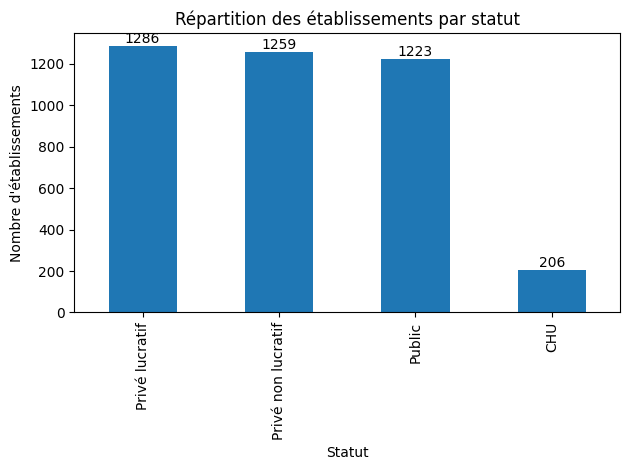

In [26]:
counts = FINESS["Statut"].value_counts()
ax = counts.plot(kind="bar")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Répartition des établissements par statut")
plt.xlabel("Statut")
plt.ylabel("Nombre d'établissements")

plt.tight_layout()
plt.show()

In [27]:
dummies = pd.get_dummies(Data["Statut"], prefix="Statut")

Data["Statut_PNL"] = dummies["Statut_Privé non lucratif"]
Data["Statut_PL"]  = dummies["Statut_Privé lucratif"]
Data["Statut_CHU"] = dummies["Statut_CHU"]

Data["Statut_PNL"] = Data["Statut_PNL"].astype(int)
Data["Statut_PL"]  = Data["Statut_PL"].astype(int)
Data["Statut_CHU"] = Data["Statut_CHU"].astype(int)

Catégorisation des variables :

In [28]:
inputs = ["lMED", "lIDE", "lAID", "lADMIN"]
outputs = ["lURG", "lMCO_HP","lMCO_HC", "lSSR", "lPSY","lSEANCES", "lUSLD"]
controles_statut = ["Statut_PNL", "Statut_PL","Statut_CHU"] 
controles_services = ["I_PSY", "I_SSR", "I_URG", "I_USLD","I_SEANCES", "I_MCO"]
controles_autres= ["lduree_MCO"]
controles_hospidiag = ["A9_imp_2022"]
interactions_statut = [f"{var}_PNL" for var in outputs] + [f"{var}_PL" for var in outputs] + [f"{var}_CHU" for var in outputs]

Ajout de variables d'outputs liées aux différentes catégories d'établissement contrôlées ("termes d'interaction") :

In [29]:
for var in outputs:
    Data[f"{var}_PNL"] = Data[var] * Data["Statut_PNL"]
    Data[f"{var}_PL"]  = Data[var] * Data["Statut_PL"]
    Data[f"{var}_CHU"]  = Data[var] * Data["Statut_CHU"]

Pour mieux mesurer le gain d'efficacité lié à la réduction de la durée des séjours, on construit la variable "lduree_MCO" contient la durée moyenne d'un séjour en hospitalisation complète en log.

In [30]:
Data["duree_MCO"] = SYGEN2022['JOU_MCO']/SYGEN2022['SEJHC_MCO']
Data["duree_MCO"] = Data["duree_MCO"].fillna(0)
Data["lduree_MCO"] = np.log(Data["duree_MCO"]+1)

On souhaite également contrôler pour la gravité des cas, pour cela on utilise l'indicateur A9 d'Hospidiag

Ajout des valeurs imputées de l'indicateur de gravité A9 d'hospidiag : 

In [31]:
A9_imputed = pd.read_csv("A9_imputed2022.csv", sep=",", decimal = ".", encoding="utf-8")
A9_imputed

,FI,A9_imp_2022
0,010000024,11.360
1,010000032,18.320
2,010000065,54.820
3,010000081,13.276
4,010000099,59.410
...,...,...
3983,980500763,0.000
3984,980500920,12.868
3985,980501159,13.474
3986,980501258,13.474


In [32]:
Data = Data.merge(A9_imputed, on="FI", how="left")

### 4 - Première approche : régression linéaire en contrôlant pour le statut

#### 4.1 - Estimation des coefficients de la demande conditionnelle

Préparation des données à la régression : 

In [33]:
X_vars = (outputs + controles_statut + controles_services + controles_autres + interactions_statut + controles_hospidiag)

Data_clean = Data[inputs + X_vars].copy()

# Conversion forcée en numérique
Data_clean = Data_clean.apply(pd.to_numeric, errors="coerce")

# Suppression des lignes inexploitables
Data_clean = Data_clean.dropna()

Data_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,...,lSEANCES_PL,lUSLD_PL,lURG_CHU,lMCO_HP_CHU,lMCO_HC_CHU,lSSR_CHU,lPSY_CHU,lSEANCES_CHU,lUSLD_CHU,A9_imp_2022
count,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,...,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000,2948.000000
mean,2.942552,3.741972,3.593996,3.078617,2.112241,3.054052,3.672775,3.293943,1.350216,1.772571,...,0.524203,0.014384,0.289539,0.407115,0.441251,0.196546,0.120006,0.284613,0.052456,16.360465
std,1.423007,1.335277,1.266089,1.271355,4.153378,4.062759,4.083718,3.029485,3.115397,3.480993,...,2.021747,0.210497,1.750673,1.853759,1.961656,1.090230,0.971786,1.605925,0.436421,12.652747
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.791759,2.708050,2.772589,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.380000
50%,2.564949,3.465736,3.496508,2.890372,0.000000,0.000000,0.000000,5.017280,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.240000
75%,4.094345,4.624973,4.406719,3.891820,0.000000,7.934507,7.954537,6.102559,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.624000
max,7.323831,7.645398,7.515889,6.859615,11.793915,10.914525,11.235352,7.921536,10.761492,11.306553,...,11.029699,3.931826,11.793915,10.698085,11.235352,7.819636,10.328723,11.273551,5.123964,94.740000


On va donc réaliser une estimation à partir de 2975 observations sur l'année 2022 (sur les 3988 observations disponibles), soit une utilisation 75%.

Estimation des coefficients : On régresse les inputs (médecins, infirmiers, aides soignantes, personnel adminisitratif) sur les outputs et les contrôles

In [34]:
results = {}
dict_diff = {}

In [35]:
for inp in inputs:
    y = Data_clean[inp]

    X = Data_clean[X_vars]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results[inp] = model

In [36]:
for inp, model in results.items():
    for statut in ["PNL", "PL", "CHU"]:
        coef_name = f"Statut_{statut}"

        if coef_name in model.params.index:
            coef = model.params[coef_name]
            pct = (np.exp(coef) - 1) * 100
            dict_diff[(inp, statut)] = pct

#### 4.2 - Résultats

In [37]:
dict_diff

{('lMED', 'PNL'): np.float64(13.713912377040472),
 ('lMED', 'PL'): np.float64(20.691534539529655),
 ('lMED', 'CHU'): np.float64(51.593672641355106),
 ('lIDE', 'PNL'): np.float64(-9.485715394421756),
 ('lIDE', 'PL'): np.float64(-14.01339920611493),
 ('lIDE', 'CHU'): np.float64(141.13097651691052),
 ('lAID', 'PNL'): np.float64(-44.2299626608039),
 ('lAID', 'PL'): np.float64(-46.13044552904728),
 ('lAID', 'CHU'): np.float64(84.95513069288346),
 ('lADMIN', 'PNL'): np.float64(32.29745760834513),
 ('lADMIN', 'PL'): np.float64(6.596442165878846),
 ('lADMIN', 'CHU'): np.float64(12.973992892454733)}

|    |    Privé Lucratif     |   Privé non lucratif    |    CHU   |
|:----------|------------:|-------------:|-------------:|
| Personnel administratif    |      +25% |        +41% |    +68%     |
| Aides-soigant.e.s      |      -39% |     -41%  |      +129%   |
| Infirmièr.e.s      |      +1% |       -3% |    +167%      |
| Médecins      |      +88% |     +27%    |       +88%  |

Tableau regroupant les différences d'emploi des différentes catégories de personnel à niveau de production égal selon la nature de l'etablissement (privé non lucratif,privé lucratif ou CHU) en prenant comme référence les hopitaux publics petits ou moyens (non CHU).

Contrôles : présence de service d'urgence, de MCO, de psychiatrie, de SSR, d'USLD, et de séances ; durée moyenne de séjour en MCO, indice de gravité A9 d'hospidiag

Contrôles à rajouter : indice de recherche/enseignement (hospidiag)

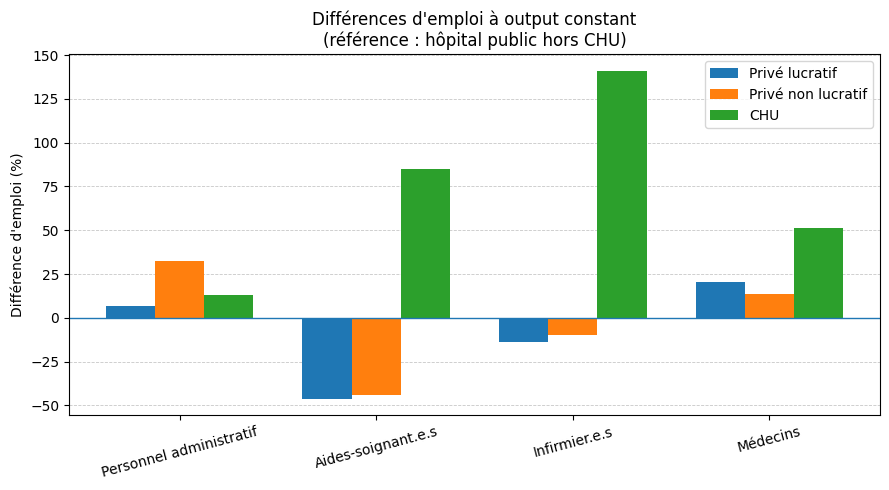

In [38]:
# Passage du dictionnaire à un DataFrame
df = pd.Series(dict_diff).unstack()

# On garde l'ordre souhaité
df = df.loc[["lADMIN", "lAID", "lIDE", "lMED"], ["PL", "PNL", "CHU"]]

# Renommage lisible
df.index = [
    "Personnel administratif",
    "Aides-soignant.e.s",
    "Infirmier.e.s",
    "Médecins"
]

df.columns = [
    "Privé lucratif",
    "Privé non lucratif",
    "CHU"
]

# Paramètres du graphique
x = np.arange(len(df.index))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))

ax.yaxis.grid(True,linestyle="--",linewidth=0.6,alpha=0.7)
ax.set_axisbelow(True)

ax.bar(x - width, df["Privé lucratif"], width, label="Privé lucratif")
ax.bar(x, df["Privé non lucratif"], width, label="Privé non lucratif")
ax.bar(x + width, df["CHU"], width, label="CHU")



# Mise en forme
ax.set_ylabel("Différence d'emploi (%)")
ax.set_title(
    "Différences d'emploi à output constant\n"
    "(référence : hôpital public hors CHU)"
)
ax.set_xticks(x)
ax.set_xticklabels(df.index, rotation=15)
ax.legend()

ax.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

Evaluation des régression : R²

In [39]:
for inp, model in results.items():
    print(f"{inp} : R² = {model.rsquared:.3f} | R² ajusté = {model.rsquared_adj:.3f}")

lMED : R² = 0.829 | R² ajusté = 0.827
lIDE : R² = 0.796 | R² ajusté = 0.793
lAID : R² = 0.714 | R² ajusté = 0.710
lADMIN : R² = 0.742 | R² ajusté = 0.739


Concernant l'influence mesurée de la durée moyenne des séjours :

In [40]:
for inp, model in results.items():
    print(f"\n{inp}")
    print(model.params["lduree_MCO"])


lMED
-0.18971527963648063

lIDE
0.011332238322365587

lAID
0.09443910357241313

lADMIN
-0.15812000846507224


Coefficients négatifs ? Très surprenant 

Effet de l'ambulatoire sur les différentes catégories de personnel :

In [41]:
for inp, model in results.items():
    print(f"{inp} : Hospitalisation complète : {model.params["lMCO_HC"]} | Hospitalisation partielle : {model.params["lMCO_HP"]}")

lMED : Hospitalisation complète : 0.251338858445762 | Hospitalisation partielle : 0.07611620481448866
lIDE : Hospitalisation complète : 0.20109758267904362 | Hospitalisation partielle : 0.05194388984651846
lAID : Hospitalisation complète : 0.16059992833715028 | Hospitalisation partielle : 0.05359794748582675
lADMIN : Hospitalisation complète : 0.20483894450093695 | Hospitalisation partielle : 0.06634195554237371


Résultats complets des régressions :

In [42]:
results["lMED"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lMED   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.827
Method:                 Least Squares   F-statistic:                     463.2
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:24:41   Log-Likelihood:                -2615.6
No. Observations:                2948   AIC:                             5311.
Df Residuals:                    2908   BIC:                             5551.
Df Model:                          39                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.7250      0.055     31.641      0.000       1.618       1.832
lURG             0.3140      0.056      5.629      0.000       0.205       0.423
lMCO_HP          0.0761      0.011      7.207      0.000       0.055       0.097
lMCO_HC          0.2513      0.018     14.095      0.000       0.216       0.286
lSSR             0.2817      0.024     11.560      0.000       0.234       0.329
lPSY             0.3837      0.029     13.295      0.000       0.327       0.440
lSEANCES         0.0626      0.015      4.091      0.000       0.033       0.093
lUSLD           -0.0068      0.040     -0.168      0.867      -0.086       0.072
Statut_PNL       0.1285      0.073      1.751      0.080      -0.015       0.272
Statut_PL        0.1881      0.075      2.502      0.012       0.041       0.335
Statut_CHU       0.4160      0.182      2.289      0.022       0.060       0.772
I_PSY           -2.1290      0.242     -8.800      0.000      -2.603      -1.655
I_SSR           -1.5221      0.140    -10.857      0.000      -1.797      -1.247
I_URG           -2.7020      0.493     -5.485      0.000      -3.668      -1.736
I_USLD          -0.1596      0.134     -1.191      0.233      -0.422       0.103
I_SEANCES       -0.4753      0.096     -4.960      0.000      -0.663      -0.287
I_MCO           -0.4069      0.106     -3.838      0.000      -0.615      -0.199
lduree_MCO      -0.1897      0.039     -4.826      0.000      -0.267      -0.113
lURG_PNL        -0.0191      0.015     -1.258      0.208      -0.049       0.011
lMCO_HP_PNL      0.0204      0.018      1.156      0.248      -0.014       0.055
lMCO_HC_PNL      0.0014      0.016      0.088      0.930      -0.029       0.032
lSSR_PNL        -0.0011      0.012     -0.092      0.927      -0.025       0.022
lPSY_PNL        -0.0083      0.013     -0.657      0.511      -0.033       0.016
lSEANCES_PNL     0.0410      0.015      2.787      0.005       0.012       0.070
lUSLD_PNL       -0.0122      0.027     -0.446      0.656      -0.066       0.041
lURG_PL         -0.0211      0.013     -1.637      0.102      -0.046       0.004
lMCO_HP_PL       0.0668      0.020      3.399      0.001       0.028       0.105
lMCO_HC_PL      -0.0539      0.020     -2.658      0.008      -0.094      -0.014
lSSR_PL         -0.0080      0.011     -0.707      0.480      -0.030       0.014
lPSY_PL         -0.0573      0.011     -5.240      0.000      -0.079      -0.036
lSEANCES_PL      0.0147      0.012      1.244      0.214      -0.008       0.038
lUSLD_PL         0.0366      0.034      1.065      0.287      -0.031       0.104
lURG_CHU     -3.642e-05      0.018     -0.002      0.998      -0.036       0.036
lMCO_HP_CHU      0.0860      0.028      3.085      0.002       0.031       0.141
lMCO_HC_CHU     -0.0772      0.030     -2.534      0.011      -0.137      -0.017
lSSR_

In [43]:
results["lIDE"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lIDE   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.793
Method:                 Least Squares   F-statistic:                     309.9
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:24:41   Log-Likelihood:                -2694.4
No. Observations:                2948   AIC:                             5469.
Df Residuals:                    2908   BIC:                             5708.
Df Model:                          39                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.9380      0.057     51.798      0.000       2.827       3.049
lURG             0.3101      0.068      4.550      0.000       0.176       0.444
lMCO_HP          0.0519      0.011      4.753      0.000       0.031       0.073
lMCO_HC          0.2011      0.021      9.507      0.000       0.160       0.243
lSSR             0.2887      0.027     10.886      0.000       0.237       0.341
lPSY             0.4702      0.032     14.753      0.000       0.408       0.533
lSEANCES         0.0907      0.019      4.822      0.000       0.054       0.128
lUSLD            0.1319      0.040      3.307      0.001       0.054       0.210
Statut_PNL      -0.0997      0.080     -1.245      0.213      -0.257       0.057
Statut_PL       -0.1510      0.078     -1.945      0.052      -0.303       0.001
Statut_CHU       0.8802      0.189      4.649      0.000       0.509       1.251
I_PSY           -2.4486      0.266     -9.199      0.000      -2.970      -1.927
I_SSR           -1.6035      0.151    -10.606      0.000      -1.900      -1.307
I_URG           -2.5591      0.588     -4.355      0.000      -3.711      -1.408
I_USLD          -0.3552      0.132     -2.686      0.007      -0.614      -0.096
I_SEANCES       -0.5985      0.109     -5.491      0.000      -0.812      -0.385
I_MCO           -0.7887      0.141     -5.575      0.000      -1.066      -0.511
lduree_MCO       0.0113      0.041      0.273      0.785      -0.070       0.093
lURG_PNL        -0.0048      0.017     -0.275      0.784      -0.039       0.029
lMCO_HP_PNL     -0.0045      0.020     -0.228      0.820      -0.043       0.034
lMCO_HC_PNL      0.0263      0.016      1.636      0.102      -0.005       0.058
lSSR_PNL         0.0217      0.013      1.685      0.092      -0.004       0.047
lPSY_PNL         0.0023      0.016      0.147      0.883      -0.029       0.033
lSEANCES_PNL     0.0239      0.017      1.373      0.170      -0.010       0.058
lUSLD_PNL       -0.0282      0.026     -1.080      0.280      -0.079       0.023
lURG_PL         -0.0108      0.016     -0.693      0.488      -0.041       0.020
lMCO_HP_PL       0.0182      0.019      0.942      0.346      -0.020       0.056
lMCO_HC_PL      -0.0342      0.019     -1.767      0.077      -0.072       0.004
lSSR_PL       -3.87e-05      0.012     -0.003      0.997      -0.023       0.023
lPSY_PL         -0.0837      0.011     -7.367      0.000      -0.106      -0.061
lSEANCES_PL      0.0338      0.014      2.373      0.018       0.006       0.062
lUSLD_PL        -0.0099      0.044     -0.223      0.824      -0.097       0.077
lURG_CHU        -0.0005      0.021     -0.022      0.982      -0.041       0.040
lMCO_HP_CHU      0.0594      0.028      2.129      0.033       0.005       0.114
lMCO_HC_CHU     -0.0826      0.029     -2.814      0.005      -0.140      -0.025
lSSR_

In [44]:
results["lAID"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   lAID   R-squared:                       0.714
Model:                            OLS   Adj. R-squared:                  0.710
Method:                 Least Squares   F-statistic:                     244.8
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:24:42   Log-Likelihood:                -3035.3
No. Observations:                2948   AIC:                             6151.
Df Residuals:                    2908   BIC:                             6390.
Df Model:                          39                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.8257      0.059     47.821      0.000       2.710       2.942
lURG             0.4074      0.064      6.363      0.000       0.282       0.533
lMCO_HP          0.0536      0.013      4.250      0.000       0.029       0.078
lMCO_HC          0.1606      0.023      6.986      0.000       0.116       0.206
lSSR             0.3271      0.029     11.454      0.000       0.271       0.383
lPSY             0.2918      0.034      8.535      0.000       0.225       0.359
lSEANCES         0.0767      0.018      4.217      0.000       0.041       0.112
lUSLD            0.1401      0.038      3.658      0.000       0.065       0.215
Statut_PNL      -0.5839      0.082     -7.097      0.000      -0.745      -0.423
Statut_PL       -0.6186      0.081     -7.629      0.000      -0.778      -0.460
Statut_CHU       0.6149      0.247      2.493      0.013       0.131       1.098
I_PSY           -1.7720      0.293     -6.043      0.000      -2.347      -1.197
I_SSR           -1.5802      0.165     -9.601      0.000      -1.903      -1.258
I_URG           -3.4420      0.554     -6.210      0.000      -4.528      -2.356
I_USLD           0.0176      0.124      0.142      0.887      -0.226       0.261
I_SEANCES       -0.5218      0.110     -4.759      0.000      -0.737      -0.307
I_MCO           -0.9436      0.161     -5.861      0.000      -1.259      -0.628
lduree_MCO       0.0944      0.047      2.011      0.044       0.002       0.186
lURG_PNL        -0.0090      0.018     -0.509      0.611      -0.044       0.026
lMCO_HP_PNL      0.0046      0.023      0.204      0.839      -0.040       0.049
lMCO_HC_PNL      0.0398      0.019      2.134      0.033       0.003       0.076
lSSR_PNL         0.0700      0.013      5.208      0.000       0.044       0.096
lPSY_PNL         0.0358      0.020      1.784      0.074      -0.004       0.075
lSEANCES_PNL     0.0239      0.016      1.479      0.139      -0.008       0.055
lUSLD_PNL        0.0558      0.031      1.829      0.067      -0.004       0.116
lURG_PL         -0.0054      0.015     -0.350      0.727      -0.036       0.025
lMCO_HP_PL       0.0034      0.023      0.146      0.884      -0.042       0.049
lMCO_HC_PL      -0.0073      0.023     -0.317      0.752      -0.052       0.038
lSSR_PL          0.0425      0.012      3.493      0.000       0.019       0.066
lPSY_PL         -0.0282      0.012     -2.348      0.019      -0.052      -0.005
lSEANCES_PL      0.0404      0.014      2.883      0.004       0.013       0.068
lUSLD_PL         0.0589      0.038      1.568      0.117      -0.015       0.133
lURG_CHU        -0.0206      0.021     -0.997      0.319      -0.061       0.020
lMCO_HP_CHU      0.0690      0.030      2.300      0.021       0.010       0.128
lMCO_HC_CHU     -0.0506      0.034     -1.481      0.138      -0.118       0.016
lSSR_

In [45]:
results["lADMIN"].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 lADMIN   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.739
Method:                 Least Squares   F-statistic:                     249.2
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:24:42   Log-Likelihood:                -2892.7
No. Observations:                2948   AIC:                             5865.
Df Residuals:                    2908   BIC:                             6105.
Df Model:                          39                                         
Covariance Type:                  HC1                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.8046      0.064     28.167      0.000       1.679       1.930
lURG             0.2737      0.061      4.458      0.000       0.153       0.394
lMCO_HP          0.0663      0.013      5.277      0.000       0.042       0.091
lMCO_HC          0.2048      0.021      9.815      0.000       0.164       0.246
lSSR             0.2379      0.028      8.613      0.000       0.184       0.292
lPSY             0.4010      0.032     12.602      0.000       0.339       0.463
lSEANCES         0.0985      0.018      5.547      0.000       0.064       0.133
lUSLD           -0.0219      0.049     -0.444      0.657      -0.119       0.075
Statut_PNL       0.2799      0.082      3.423      0.001       0.120       0.440
Statut_PL        0.0639      0.073      0.880      0.379      -0.078       0.206
Statut_CHU       0.1220      0.258      0.472      0.637      -0.384       0.628
I_PSY           -2.1845      0.265     -8.241      0.000      -2.704      -1.665
I_SSR           -1.2173      0.157     -7.739      0.000      -1.526      -0.909
I_URG           -2.1696      0.533     -4.069      0.000      -3.215      -1.125
I_USLD          -0.0218      0.163     -0.134      0.894      -0.341       0.298
I_SEANCES       -0.6575      0.104     -6.293      0.000      -0.862      -0.453
I_MCO           -0.3459      0.130     -2.653      0.008      -0.601      -0.090
lduree_MCO      -0.1581      0.044     -3.574      0.000      -0.245      -0.071
lURG_PNL        -0.0244      0.018     -1.363      0.173      -0.059       0.011
lMCO_HP_PNL      0.0321      0.020      1.599      0.110      -0.007       0.071
lMCO_HC_PNL     -0.0437      0.016     -2.697      0.007      -0.075      -0.012
lSSR_PNL         0.0391      0.013      2.901      0.004       0.013       0.065
lPSY_PNL         0.0067      0.015      0.448      0.654      -0.023       0.036
lSEANCES_PNL     0.0617      0.018      3.511      0.000       0.027       0.096
lUSLD_PNL       -0.0353      0.030     -1.178      0.239      -0.094       0.023
lURG_PL         -0.0255      0.014     -1.776      0.076      -0.054       0.003
lMCO_HP_PL       0.0313      0.018      1.771      0.077      -0.003       0.066
lMCO_HC_PL      -0.0675      0.018     -3.821      0.000      -0.102      -0.033
lSSR_PL          0.0106      0.011      0.954      0.340      -0.011       0.032
lPSY_PL         -0.0803      0.011     -7.538      0.000      -0.101      -0.059
lSEANCES_PL      0.0108      0.013      0.831      0.406      -0.015       0.036
lUSLD_PL        -0.0105      0.044     -0.241      0.810      -0.096       0.075
lURG_CHU         0.0024      0.020      0.116      0.908      -0.038       0.042
lMCO_HP_CHU      0.1145      0.037      3.112      0.002       0.042       0.187
lMCO_HC_CHU     -0.0884      0.042     -2.087      0.037      -0.171      -0.005
lSSR_

Dans tous les cas, on constate que les coefficients associés au statut (PL,PNL ou CHU) affichent une forte significativité statistique, ce qui vient donner une certaine robustesse aux resultats. Voyons tout de même si l'on trouve des résultats identiques en procédant à des régressions séparées.

### 5 - Deuxième approche : régressions linéaires séparées pour chaque catégorie d'établissement

#### 5.1 - Séparation des données en quatre selon le statut de l'établissement :

In [46]:
Data_CHU = Data[Data["Statut"] == "CHU"]
Data_PNL = Data[Data["Statut"] == "Privé non lucratif"]
Data_PL = Data[Data["Statut"] == "Privé lucratif"]
Data_PHP = Data[Data["Statut"] == "Public"]

#### 5.2 - Préparation des données :

In [47]:
X_vars2 = (outputs + controles_services + controles_autres + controles_hospidiag)

In [48]:
Data_CHU_clean = Data_CHU[inputs + X_vars2].copy()
Data_CHU_clean = Data_CHU_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_CHU_clean = Data_CHU_clean.dropna() # Suppression des lignes inexploitables
Data_CHU_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,4.535845,5.456158,5.349676,4.351697,4.849784,6.819177,7.390950,3.292152,2.010105,4.767274,0.878638,0.261364,0.539773,0.448864,0.250000,0.528409,0.875000,1.743273,12.297057
std,1.641376,1.392721,1.265897,1.671700,5.419373,3.727535,3.625398,3.125160,3.475940,4.683810,1.573955,0.440631,0.499838,0.498797,0.434248,0.500617,0.331662,0.866378,5.700886
min,0.693147,1.945910,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030000
25%,3.124381,4.248495,4.494191,3.044522,0.000000,5.742036,6.396044,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.660443,10.110000
50%,4.639467,5.523457,5.498962,4.605120,0.000000,8.445588,8.603625,4.543295,0.000000,6.228739,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.891958,11.225000
75%,6.019807,6.729222,6.391879,5.871377,10.917097,9.518097,10.132258,6.210994,4.909889,9.484843,0.486478,1.000000,1.000000,1.000000,0.250000,1.000000,1.000000,2.181796,12.450000
max,7.323831,7.645398,7.515889,6.859615,11.793915,10.698085,11.235352,7.819636,10.328723,11.273551,5.123964,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.422965,40.710000


In [49]:
Data_PL_clean = Data_PL[inputs + X_vars2].copy()
Data_PL_clean = Data_PL_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PL_clean = Data_PL_clean.dropna() # Suppression des lignes inexploitables
Data_PL_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000,946.000000
mean,3.018576,3.499093,3.127641,2.822357,1.232683,3.686750,3.498014,2.801581,1.123823,1.633563,0.044826,0.140592,0.438689,0.123679,0.015856,0.208245,0.449260,0.670266,11.468444
std,1.210379,0.952124,0.944242,0.824897,3.287617,4.421750,4.055306,3.199175,2.821621,3.306463,0.369881,0.347784,0.496489,0.329389,0.124985,0.406268,0.497682,0.805304,9.957827
min,0.000000,0.693147,0.000000,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.945910,2.833213,2.484907,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.610000
50%,2.708050,3.367296,3.178054,2.708050,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.967000
75%,4.123069,4.127134,3.761200,3.401197,0.000000,8.874553,7.981306,6.388141,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.469342,16.132000
max,5.641907,6.208590,5.891644,5.117994,11.174652,10.914525,10.290857,7.798523,10.141559,11.029699,3.931826,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.874667,85.380000


In [50]:
Data_PNL_clean = Data_PNL[inputs + X_vars2].copy()
Data_PNL_clean = Data_PNL_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PNL_clean = Data_PNL_clean.dropna() # Suppression des lignes inexploitables
Data_PNL_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000
mean,2.458146,3.318888,3.138190,2.920821,0.493618,1.500290,1.796949,3.363196,0.766529,0.863542,0.228877,0.098529,0.547059,0.048529,0.073529,0.098529,0.245588,0.486017,17.005903
std,1.174006,1.112570,1.121619,1.086999,2.191795,3.189822,3.314464,3.105725,2.379750,2.695647,0.830352,0.298249,0.498147,0.215040,0.261196,0.298249,0.430752,0.919495,10.564443
min,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.609438,2.564949,2.397895,2.197225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.512000
50%,2.079442,3.178054,3.218876,2.833213,0.000000,0.000000,0.000000,5.233747,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.778000
75%,3.044522,3.891820,3.871201,3.496508,0.000000,0.000000,0.000000,6.250939,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.200000
max,6.253829,6.655440,6.188264,6.276643,11.466002,10.614499,10.658929,7.921536,10.192681,11.306553,4.094345,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.932230,53.424000


In [51]:
Data_PHP_clean = Data_PHP[inputs + X_vars2].copy()
Data_PHP_clean = Data_PHP_clean.apply(pd.to_numeric, errors="coerce") # Conversion forcée en numérique
Data_PHP_clean = Data_PHP_clean.dropna() # Suppression des lignes inexploitables
Data_PHP_clean.describe()

,lMED,lIDE,lAID,lADMIN,lURG,lMCO_HP,lMCO_HC,lSSR,lPSY,lSEANCES,lUSLD,I_PSY,I_SSR,I_URG,I_USLD,I_SEANCES,I_MCO,lduree_MCO,A9_imp_2022
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,2.969625,3.997344,4.064795,3.239833,3.565492,2.939879,4.504255,3.710486,1.823995,2.043021,1.259548,0.208333,0.655556,0.350000,0.388889,0.256481,0.603704,1.289715,20.806139
std,1.497282,1.461235,1.170082,1.470207,4.879014,3.775402,4.012500,2.751318,3.602783,3.594510,1.628804,0.406305,0.475407,0.477191,0.487724,0.436893,0.489354,1.140179,14.808105
min,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.609438,2.708050,3.258097,2.079442,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.400000
50%,2.772589,3.713572,3.988984,3.113268,0.000000,0.000000,5.409409,5.308268,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.738610,14.820000
75%,4.234107,5.298317,4.884689,4.502572,9.714420,7.472784,8.357611,5.852920,0.000000,4.237704,3.044522,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.119583,22.940000
max,6.368187,7.138073,6.824374,6.466145,11.624735,9.871790,10.838953,7.560080,10.761492,11.015970,4.753590,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.562466,94.740000


On va donc réaliser des régressions linéaires sur des jeux de données de 192 à 1118 lignes

#### 5.3 - Estimations par catégorie d'établissement

Estimation de la fonction de demande conditionnelle des CHU :

In [52]:
results_CHU = {}

for inp in inputs:
    y = Data_CHU_clean[inp]

    X = Data_CHU_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_CHU[inp] = model

Estimation de la fonction de demande conditionnelle des établissements privés à but lucratif :

In [53]:
results_PL = {}

for inp in inputs:
    y = Data_PL_clean[inp]

    X = Data_PL_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PL[inp] = model

Estimation de la fonction de demande conditionnelle des établissements privés à but non lucratif :

In [54]:
results_PNL = {}

for inp in inputs:
    y = Data_PNL_clean[inp]

    X = Data_PNL_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PNL[inp] = model

Estimation de la fonction de demande conditionnelle des établissements publics non CHU :

In [55]:
results_PHP = {}

for inp in inputs:
    y = Data_PHP_clean[inp]

    X = Data_PHP_clean[X_vars2]
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_PHP[inp] = model

[A suivre]

### 6 - Analyse causale par variables instrumentales

Utilisation des données de 2019 comme instruments

#### 6.1 - Préparation des données

Extraction des données :

In [56]:
SYGEN2019 = pd.read_csv("SAE/2019/SYGEN_2019.csv", sep=";", encoding="latin-1")
Data2019 = SYGEN2019[['FI','FI_EJ','EFFSAL_TOT','EFFLIB_TOT','EFF_INFSANSSPE','EFF_INFAVECSPE','EFF_AID','EFF_DIR','EFF_AUTADM','SEJHC_SSR','SEJHC_MCO','SEJHP_MCO','SEJ_HTP_TOT','VEN_HDJ_TOT','VEN_HDN_TOT','SEAN_HEMO_CENTRE','SEAN_CHIMIO','SEAN_RADIO']]
Data2019 = Data2019.merge(FINESS, on="FI", how="left")

In [57]:
Urg2019 = pd.read_csv("SAE/2019/URGENCES2_2019.csv", sep=";", encoding="latin-1")
Urg2019 = Urg2019[['FI','PASSU']]
Urg2019 = Urg2019.groupby("FI").sum().reset_index()
Data2019 = Data2019.merge(Urg2019, on="FI", how="left")

In [58]:
USLD2019 = pd.read_csv("SAE/2019/USLD_2019.csv", sep=";", encoding="latin-1")
USLD2019 = USLD2019[['FI','ENT']]
Data2019 = Data2019.merge(USLD2019, on="FI", how="left")

Catégorie de personnel (Inputs) :

In [59]:
Data2019['EFF_MED'] = Data2019['EFFSAL_TOT'] + Data2019['EFFLIB_TOT'].fillna(0)
Data2019['EFF_IDE'] = Data2019['EFF_INFSANSSPE'] + Data2019['EFF_INFAVECSPE'].fillna(0)
Data2019['EFF_ADMIN'] = Data2019['EFF_AUTADM'] + Data2019['EFF_DIR'].fillna(0)

Outputs :

In [60]:
Data2019['PSY'] = Data2019['SEJ_HTP_TOT'] + Data2019['VEN_HDJ_TOT'].fillna(0) + Data2019['VEN_HDN_TOT'].fillna(0)
Data2019['PSY'] = Data2019['PSY'].fillna(0)
Data2019['I_PSY_2019'] = (Data2019['PSY'] > 0).astype(int)

Data2019['MCO'] = Data2019['SEJHP_MCO'] + Data2019['SEJHC_MCO']
Data2019['MCO'] = Data2019['MCO'].fillna(0)
Data2019['I_MCO_2019'] = (Data2019['MCO'] > 0).astype(int)

Data2019['SEANCES'] = Data2019['SEAN_HEMO_CENTRE'].fillna(0) + Data2019['SEAN_CHIMIO'] + Data2019['SEAN_RADIO'].fillna(0)
Data2019['SEANCES'] = Data2019['SEANCES'].fillna(0)
Data2019['I_SEANCES_2019'] = (Data2019['SEANCES'] > 0).astype(int)

Data2019['PASSU'] = Data2019['PASSU'].fillna(0)
Data2019['I_URG_2019'] = (Data2019['PASSU'] > 0).astype(int)

Data2019['ENT'] = Data2019['ENT'].fillna(0)
Data2019['I_USLD_2019'] = (Data2019['ENT'] > 0).astype(int)

Data2019['SEJHC_SSR'] = Data2019['SEJHC_SSR'].fillna(0)
Data2019['I_SSR_2019'] = (Data2019['SEJHC_SSR'] > 0).astype(int)

Passage au log :

In [61]:
Data2019['lURG_2019'] = np.log(Data2019['PASSU']+1)
Data2019['lMCO_HC_2019'] = np.log(SYGEN2019['SEJHC_MCO'].fillna(0)+1)
Data2019['lMCO_HP_2019'] = np.log(SYGEN2019['SEJHP_MCO'].fillna(0)+1)
Data2019['lPSY_2019'] = np.log(Data2019['PSY']+1)
Data2019['lSSR_2019'] = np.log(Data2019['SEJHC_SSR']+1)
Data2019['lSEANCES_2019'] = np.log(Data2019['SEANCES']+1)
Data2019['lUSLD_2019'] = np.log(Data2019['ENT']+1)

Data2019['lMED_2019'] = np.log(Data2019['EFF_MED']+1)
Data2019['lIDE_2019'] = np.log(Data2019['EFF_IDE']+1)
Data2019['lAID_2019'] = np.log(Data2019['EFF_AID']+1)
Data2019['lADMIN_2019'] = np.log(Data2019['EFF_ADMIN']+1)

Indicatrices de statut :

In [63]:
dummies_2019 = pd.get_dummies(Data2019['Statut'], prefix='Statut')

Data2019['Statut_PNL_2019'] = dummies_2019['Statut_Privé non lucratif']
Data2019['Statut_PL_2019']  = dummies_2019['Statut_Privé lucratif']
Data2019['Statut_CHU_2019'] = dummies_2019['Statut_CHU']

Data2019['Statut_PNL_2019'] = Data2019['Statut_PNL_2019'].astype(int)
Data2019['Statut_PL_2019']  = Data2019['Statut_PL_2019'].astype(int)
Data2019['Statut_CHU_2019'] = Data2019['Statut_CHU_2019'].astype(int)

Hospidiag :

In [64]:
A9_imputed_2019 = pd.read_csv("A9_imputed2019.csv", sep=",", decimal = ".", encoding="utf-8")
Data2019 = Data2019.merge(A9_imputed_2019, on="FI", how="left")

Durée séjours MCO :

In [65]:
dureeMCO_2019 = SYGEN2019['JOU_MCO']/SYGEN2019['SEJHC_MCO']
Data2019["duree_MCO_2019"] = dureeMCO_2019.fillna(0)
Data2019["lduree_MCO_2019"] = np.log(Data2019["duree_MCO_2019"]+1)

Interactions :

In [67]:
for var in ["lURG_2019", "lMCO_HC_2019","lMCO_HP_2019", "lSSR_2019", "lPSY_2019","lSEANCES_2019", "lUSLD_2019"]:
    Data2019[f"{var}_PNL"] = Data2019[var] * Data2019["Statut_PNL_2019"]
    Data2019[f"{var}_PL"]  = Data2019[var] * Data2019["Statut_PL_2019"]
    Data2019[f"{var}_CHU"]  = Data2019[var] * Data2019["Statut_CHU_2019"]

categorisation des variables :

In [68]:
inputs_2019 = ["lMED_2019","lIDE_2019","lAID_2019","lADMIN_2019"]
outputs_2019 = ["lURG_2019", "lMCO_HC_2019","lMCO_HP_2019", "lSSR_2019", "lPSY_2019","lSEANCES_2019", "lUSLD_2019"]
controles_statut_2019 = ["Statut_PNL_2019", "Statut_PL_2019","Statut_CHU_2019"]
controles_services_2019 = ["I_PSY_2019", "I_SSR_2019", "I_URG_2019", "I_USLD_2019","I_SEANCES_2019", "I_MCO_2019"]
controles_autres_2019= ["lduree_MCO_2019"]
interactions_statut_2019 = [f"{var}_PNL" for var in outputs_2019] + [f"{var}_PL" for var in outputs_2019] + [f"{var}_CHU" for var in outputs_2019]
controles_hospidiag_2019 = ["A9_imp_2019"]

Données utiles :

In [69]:
Data_instr = Data[['FI'] + inputs + outputs + controles_statut + controles_services + controles_autres + interactions_statut + controles_hospidiag]
Data_instr = Data_instr.merge(Data2019[['FI']+inputs_2019 + outputs_2019 + controles_statut_2019 + controles_services_2019 + controles_autres_2019 + interactions_statut_2019 + controles_hospidiag_2019], on="FI", how="inner")
print(Data_instr.shape) 

(3824, 87)


#### 6.2 - Vérification de la pertinence des instruments

Analyse des corrélations entre les variables de 2022 et leurs équivalents de 2019 :

In [70]:
for var in outputs:
    corr = Data_instr[var].corr(Data_instr[f"{var}_2019"])
    print(var, round(corr,3))

lURG 0.989
lMCO_HP 0.98
lMCO_HC 0.991
lSSR 0.978
lPSY 0.982
lSEANCES 0.947
lUSLD 0.966


On observe une corrélation proche de 1 (>0.95), pour chacun des outputs considérés, entre 2019 et 2022, d'où la pertinence d'utiliser les outputs de 2019 comme instruments.

In [76]:
for i in range(len(interactions_statut)):
    var = interactions_statut[i]
    var_2019 = interactions_statut_2019[i]
    corr = Data_instr[var].corr(Data_instr[var_2019])
    print(var, round(corr,3))

lURG_PNL 0.951
lMCO_HP_PNL 0.902
lMCO_HC_PNL 0.884
lSSR_PNL 0.996
lPSY_PNL 0.972
lSEANCES_PNL 0.924
lUSLD_PNL 0.959
lURG_PL 0.989
lMCO_HP_PL 0.958
lMCO_HC_PL 0.957
lSSR_PL 0.987
lPSY_PL 0.993
lSEANCES_PL 0.939
lUSLD_PL 0.968
lURG_CHU 0.993
lMCO_HP_CHU 0.958
lMCO_HC_CHU 0.953
lSSR_CHU 0.974
lPSY_CHU 0.977
lSEANCES_CHU 0.977
lUSLD_CHU 0.944


De façon cohérente, on retrouve une forte corrélation sur les termes d'interaction que l'on va également instrumenter.

In [71]:
Data_instr.columns

Index(['FI', 'lMED', 'lIDE', 'lAID', 'lADMIN', 'lURG', 'lMCO_HP', 'lMCO_HC',
       'lSSR', 'lPSY', 'lSEANCES', 'lUSLD', 'Statut_PNL', 'Statut_PL',
       'Statut_CHU', 'I_PSY', 'I_SSR', 'I_URG', 'I_USLD', 'I_SEANCES', 'I_MCO',
       'lduree_MCO', 'lURG_PNL', 'lMCO_HP_PNL', 'lMCO_HC_PNL', 'lSSR_PNL',
       'lPSY_PNL', 'lSEANCES_PNL', 'lUSLD_PNL', 'lURG_PL', 'lMCO_HP_PL',
       'lMCO_HC_PL', 'lSSR_PL', 'lPSY_PL', 'lSEANCES_PL', 'lUSLD_PL',
       'lURG_CHU', 'lMCO_HP_CHU', 'lMCO_HC_CHU', 'lSSR_CHU', 'lPSY_CHU',
       'lSEANCES_CHU', 'lUSLD_CHU', 'A9_imp_2022', 'lMED_2019', 'lIDE_2019',
       'lAID_2019', 'lADMIN_2019', 'lURG_2019', 'lMCO_HC_2019', 'lMCO_HP_2019',
       'lSSR_2019', 'lPSY_2019', 'lSEANCES_2019', 'lUSLD_2019',
       'Statut_PNL_2019', 'Statut_PL_2019', 'Statut_CHU_2019', 'I_PSY_2019',
       'I_SSR_2019', 'I_URG_2019', 'I_USLD_2019', 'I_SEANCES_2019',
       'I_MCO_2019', 'lduree_MCO_2019', 'lURG_2019_PNL', 'lMCO_HC_2019_PNL',
       'lMCO_HP_2019_PNL', 'lSSR_2019_

In [73]:
Data_instr = Data_instr.dropna()
print(Data_instr.shape)

(2760, 87)


#### 6.3 - Estimations par la méthode des doubles moindres carrés

Estimations en instrumentant les outputs et les termes d'interaction associés :

In [80]:
endog_vars = outputs + interactions_statut
instr_vars = outputs + interactions_statut_2019
controles = controles_statut + controles_services + controles_autres + controles_hospidiag

endog_str = " + ".join(endog_vars)
instr_str = " + ".join(instr_vars)
control_str = " + ".join(controles)

result_instr = {}

for inp in inputs:

    formula = f"""
    {inp} ~ 1
    + {control_str}
    + [{endog_str} ~ {instr_str}]
    """

    model = IV2SLS.from_formula(
        formula,
        data=Data_instr
    )

    res = model.fit(cov_type="robust")

    result_instr[inp] = res

c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T
c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T
c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T
c:\Users\Alexandre\AppData\Local\Programs\Python\Python312\Lib\site-packages\linearmodels\shared\linalg.py:64: RuntimeWarning: invalid value encountered in sqrt
  return vecs @ np.diag(1 / np.sqrt(vals)) @ vecs.T


#### 6.4 - Analyse des résultats

In [83]:
#Affichage des résultats des régressions avec variables instrumentales pour les Médecins

print("\n========================")
print("Résultat pour lMED")
print("========================")
print(result_instr['lMED'].summary)


Résultat pour lMED
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lMED   R-squared:                      0.8364
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8340
No. Observations:                2760   F-statistic:                 1.804e+04
Date:                Wed, Mar 11 2026   P-value (F-stat)                0.0000
Time:                        10:47:14   Distribution:                 chi2(39)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        1.7961     0.0572     31.390     0.0000      1.6839      1.9082
Statut_PNL       0.0341 

In [84]:
#Affichage des résultats des régressions avec variables instrumentales pour les Infirmier.e.s

print("\n========================")
print("Résultat pour lIDE")
print("========================")
print(result_instr['lIDE'].summary)


Résultat pour lIDE
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lIDE   R-squared:                      0.8035
Estimator:                    IV-2SLS   Adj. R-squared:                 0.8007
No. Observations:                2760   F-statistic:                 1.194e+04
Date:                Wed, Mar 11 2026   P-value (F-stat)                0.0000
Time:                        10:47:14   Distribution:                 chi2(39)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        3.0223     0.0598     50.569     0.0000      2.9052      3.1394
Statut_PNL      -0.1563 

In [85]:
#Affichage des résultats des régressions avec variables instrumentales pour les Aides-soignant.e.s

print("\n========================")
print("Résultat pour lAID")
print("========================")
print(result_instr['lAID'].summary)


Résultat pour lAID
                          IV-2SLS Estimation Summary                          
Dep. Variable:                   lAID   R-squared:                      0.7259
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7219
No. Observations:                2760   F-statistic:                    9928.5
Date:                Wed, Mar 11 2026   P-value (F-stat)                0.0000
Time:                        10:47:14   Distribution:                 chi2(39)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        2.9514     0.0621     47.554     0.0000      2.8298      3.0731
Statut_PNL      -0.6264 

In [86]:
#Affichage des résultats des régressions avec variables instrumentales pour le personnel administratif

print("\n========================")
print("Résultat pour lADMIN")
print("========================")
print(result_instr['lADMIN'].summary)


Résultat pour lADMIN
                          IV-2SLS Estimation Summary                          
Dep. Variable:                 lADMIN   R-squared:                      0.7526
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7490
No. Observations:                2760   F-statistic:                    9685.9
Date:                Wed, Mar 11 2026   P-value (F-stat)                0.0000
Time:                        10:47:22   Distribution:                 chi2(39)
Cov. Estimator:                robust                                         
                                                                              
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
Intercept        1.8897     0.0665     28.406     0.0000      1.7593      2.0200
Statut_PNL       0.194